In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# Import Library

In [3]:
pip install sastrawi Tensorflow

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\AR2R\machine_learning_terapan\p2\p2env\Scripts\python.exe -m pip install --upgrade pip' command.


Melakukan Install modul yang diperlukann

In [4]:
import pandas as pd
import random
import numpy as np
import re
import string
import nltk
import random
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix, hstack
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

<h2> Import Library dan Modul <br>

Pada bagian ini, saya mengimpor berbagai library yang digunakan dalam proyek ini.
Saya juga melakukan pengunduhan resource dari NLTK yang diperlukan untuk tokenisasi, stopword, dan lemmatization.


# Data Load

In [5]:
books_df = pd.read_csv('dataset/Books.csv')
ratings_df = pd.read_csv('dataset/Ratings.csv')
users_df = pd.read_csv('dataset/Users.csv')


C:\Users\USER\AppData\Local\Temp\ipykernel_16844\4128249743.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books_df = pd.read_csv('dataset/Books.csv')


Pada kode ini saya melakukan Loading pada 3 dataset yaitu Books.csv,  Ratings.csv dan  Users.csv

# Data Understanding

In [6]:
books_df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


Cell ini digunakan untuk melihat data awal dari Book.csv

In [7]:
books_df.isna().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

Saya melakukan pengecekan apakah ada data yang kosong atau tidak. dan saya menemukan data kosong pada:
- Book-Author = 2
- Publisher = 2
- Image-URL-L = 3

In [8]:
books_df.duplicated().sum()

np.int64(0)

Ketika saya melakukan oengecekan terhadap cata duplikat. Saya menemukan 0 data duplikat

In [9]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


Ketika melihat informasi mengenai data ternyata terpadat 271360 entries pada data ini

In [10]:

ratings_df.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [11]:
ratings_df.isna().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

Saya melakukan juga terhadap data Ratings.csv dan tidak menemukan data kosong pada data tersebut.

In [12]:
ratings_df.duplicated().sum()

np.int64(0)

Data ini juga tidak memiliki duplikasi

In [13]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


Ketika melihat informasi mengenai data Ratings.csv terdapat 1149780 entries dari data ini.

In [14]:
users_df.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [15]:
users_df.isna().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

Untuk User.csv saya menemukan ada data kosong sebanyak 110762 pada kolom 'Age'

In [16]:
users_df.duplicated().sum()

np.int64(0)

tidak ada duplikat pada data User.csv

In [17]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB



Dataset yang digunakan berasal dari Kaggle dan terdiri dari tiga file utama: **Books.csv**, **Ratings.csv**, dan **Users.csv**. Ketiga dataset ini merepresentasikan sistem rekomendasi buku berdasarkan informasi buku, pengguna, dan penilaian mereka terhadap buku.

<h5> 1. Books.csv <br>
Dataset ini memuat informasi tentang buku yang tersedia dalam sistem. Dataset ini terdiri dari 8 kolom dan 121.164 baris data. Terdapat 6 baris data kosong, namun tidak ditemukan data duplikat.

**Fitur-fitur:**
- `ISBN`: Nomor identifikasi unik untuk setiap buku (International Standard Book Number).
- `Book-Title`: Judul buku.
- `Book-Author`: Nama penulis buku.
- `Year-Of-Publication`: Tahun terbit buku.
- `Publisher`: Nama penerbit buku.
- `Image-URL-S`: URL gambar sampul buku ukuran kecil.
- `Image-URL-M`: URL gambar sampul buku ukuran sedang.
- `Image-URL-L`: URL gambar sampul buku ukuran besar.

---

<h5> 2. Ratings.csv <br>
Dataset ini mencatat penilaian (rating) yang diberikan oleh pengguna terhadap buku. Dataset ini terdiri dari 3 kolom dan 1.149.780 baris data. Tidak terdapat nilai kosong maupun data duplikat.

**Fitur-fitur:**
- `User-ID`: Identitas unik pengguna.
- `ISBN`: Identitas unik buku yang dinilai.
- `Book-Rating`: Nilai rating yang diberikan oleh pengguna terhadap buku.

---

<h5> 3. Users.csv <br>
Dataset ini menyimpan informasi tentang pengguna. Terdiri dari 3 kolom dan 278.858 baris data. Terdapat 110.762 nilai kosong, khususnya pada kolom 'Age', namun tidak ditemukan data duplikat.

**Fitur-fitur:**
- `User-ID`: Identitas unik pengguna.
- `Location`: Lokasi geografis pengguna dalam format “Kota, Negara Bagian, Negara”.
- `Age`: Usia pengguna.


## Univariate Exploratory Data Analysis

### Books Variabel

In [18]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


Pada cell ini dilakukan inspeksi struktur dataframe `books_df`, yang memuat informasi:
- Jumlah total baris: 271.360
- Total kolom: 8
- Semua kolom bertipe objek (string), termasuk `Year-Of-Publication` yang seharusnya numerik.
- Terdapat beberapa nilai null pada kolom `Book-Author`, `Publisher`, dan `Image-URL-L`.

Langkah ini penting untuk memahami kualitas dan struktur data sebelum diproses lebih lanjut.

In [19]:
unique_isbn = books_df['ISBN'].unique()
print(f"Jumlah ISBN unik: {len(unique_isbn)}")

Jumlah ISBN unik: 271360


In [20]:
print("Contoh Judul Buku:", books_df['Book-Title'].unique()[:100])

Contoh Judul Buku: ['Classical Mythology' 'Clara Callan' 'Decision in Normandy'
 'Flu: The Story of the Great Influenza Pandemic of 1918 and the Search for the Virus That Caused It'
 'The Mummies of Urumchi' "The Kitchen God's Wife"
 "What If?: The World's Foremost Military Historians Imagine What Might Have Been"
 'PLEADING GUILTY'
 'Under the Black Flag: The Romance and the Reality of Life Among the Pirates'
 "Where You'll Find Me: And Other Stories" 'Nights Below Station Street'
 "Hitler's Secret Bankers: The Myth of Swiss Neutrality During the Holocaust"
 'The Middle Stories' 'Jane Doe'
 "A Second Chicken Soup for the Woman's Soul (Chicken Soup for the Soul Series)"
 'The Witchfinder (Amos Walker Mystery Series)'
 'More Cunning Than Man: A Social History of Rats and Man'
 'Goodbye to the Buttermilk Sky' 'The Testament'
 'Beloved (Plume Contemporary Fiction)'
 "Our Dumb Century: The Onion Presents 100 Years of Headlines from America's Finest News Source"
 'New Vegetarian: Bold and B

Analisis ini mencakup:
- Jumlah ISBN unik pada dataset buku, menunjukkan tidak ada duplikasi ISBN.
- Contoh 100 judul buku pertama yang membantu memahami keberagaman dan format data judul.

In [21]:
print("Jumlah Penulis Unik:", books_df['Book-Author'].nunique())

Jumlah Penulis Unik: 102022


Dihitung total jumlah penulis unik (`Book-Author`) dalam dataset. Informasi ini bisa digunakan untuk analisis distribusi penulis atau filtering terhadap penulis populer.

In [22]:
# Convert 'Year-Of-Publication' to numeric, coercing errors to NaN
books_df['Year-Of-Publication'] = pd.to_numeric(books_df['Year-Of-Publication'], errors='coerce')

# Drop rows where 'Year-Of-Publication' is NaN after coercion
books_df.dropna(subset=['Year-Of-Publication'], inplace=True)

# Convert the column to integer type after removing NaNs
books_df['Year-Of-Publication'] = books_df['Year-Of-Publication'].astype(int)

print("Tahun Publikasi Unik:", books_df['Year-Of-Publication'].unique())
print("Range Tahun Publikasi:",
      books_df['Year-Of-Publication'].min(),
      "-",
      books_df['Year-Of-Publication'].max())

Tahun Publikasi Unik: [2002 2001 1991 1999 2000 1993 1996 1988 2004 1998 1994 2003 1997 1983
 1979 1995 1982 1985 1992 1986 1978 1980 1952 1987 1990 1981 1989 1984
    0 1968 1961 1958 1974 1976 1971 1977 1975 1965 1941 1970 1962 1973
 1972 1960 1966 1920 1956 1959 1953 1951 1942 1963 1964 1969 1954 1950
 1967 2005 1957 1940 1937 1955 1946 1936 1930 2011 1925 1948 1943 1947
 1945 1923 2020 1939 1926 1938 2030 1911 1904 1949 1932 1928 1929 1927
 1931 1914 2050 1934 1910 1933 1902 1924 1921 1900 2038 2026 1944 1917
 1901 2010 1908 1906 1935 1806 2021 2012 2006 1909 2008 1378 1919 1922
 1897 2024 1376 2037]
Range Tahun Publikasi: 0 - 2050


Karena kolom `Year-Of-Publication` awalnya bertipe string, langkah ini:
- Mengubah ke tipe numerik menggunakan `pd.to_numeric()`, memaksa nilai tidak valid menjadi `NaN`.
- Menghapus baris dengan `NaN` pada tahun publikasi.
- Mengonversi kolom tersebut menjadi `int`.

Kemudian ditampilkan nilai-nilai unik dari tahun publikasi dan jangkauannya (min hingga max). Terlihat adanya nilai anomali seperti tahun `0`, `1376`, `2038`, `2050`, yang bisa diproses di tahap validasi berikutnya.

In [23]:
print("Jumlah Penerbit Unik:", books_df['Publisher'].nunique())
for col in ['Image-URL-S', 'Image-URL-M', 'Image-URL-L']:
    null_count = books_df[col].isnull().sum()
    unique_urls = books_df[col].nunique()
    print(f"{col}: {unique_urls} URL unik, {null_count} data kosong")

Jumlah Penerbit Unik: 16804
Image-URL-S: 271041 URL unik, 0 data kosong
Image-URL-M: 271041 URL unik, 0 data kosong
Image-URL-L: 271041 URL unik, 0 data kosong


Dilakukan:
- Perhitungan jumlah penerbit unik (`Publisher`), menandakan banyaknya variasi asal buku.
- Pengecekan kolom `Image-URL-S`, `Image-URL-M`, dan `Image-URL-L` untuk:
  - Jumlah URL unik (yang mewakili gambar sampul).
  - Jumlah data kosong (null).

Hasilnya menunjukkan sebagian besar data memiliki URL gambar, meski jumlahnya tidak sepenuhnya unik.


### Ratings Variabel

In [24]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


Menampilkan struktur dataframe `ratings_df`:
- Jumlah baris: 1.149.780
- Kolom: `User-ID`, `ISBN`, `Book-Rating`
- Tidak terdapat missing value
- Semua kolom bertipe sesuai (int untuk rating dan ID, object untuk ISBN)

In [25]:
unique_users = ratings_df['User-ID'].nunique()
print(f"Jumlah User unik: {unique_users}")


Jumlah User unik: 105283


In [26]:
unique_isbn = ratings_df['ISBN'].nunique()
print(f"Jumlah ISBN unik: {unique_isbn}")


Jumlah ISBN unik: 340556


In [27]:
print("Nilai rating unik:", ratings_df['Book-Rating'].unique())
print("Jumlah nilai rating unik:", ratings_df['Book-Rating'].nunique())

# Jika ingin melihat distribusi rating
print("Distribusi rating buku:")
print(ratings_df['Book-Rating'].value_counts().sort_index())


Nilai rating unik: [ 0  5  3  6  8  7 10  9  4  1  2]
Jumlah nilai rating unik: 11
Distribusi rating buku:
Book-Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64


Langkah ini mengevaluasi:
- Jumlah user unik yang memberikan rating
- Jumlah ISBN yang pernah diberi rating
- Distribusi nilai rating, dari 0 hingga 10 (total 11 level)

Rating `0` tampak mendominasi (lebih dari 700 ribu), yang bisa diinterpretasikan sebagai *no rating* atau *implicit feedback*, tergantung konteks penggunaannya.

### Users Variabel

In [28]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB



Menampilkan informasi tentang pengguna:
- Total user: 278.858
- Kolom: `User-ID`, `Location`, `Age`
- Kolom `Age` memiliki cukup banyak nilai kosong (hanya 168.096 yang valid)

In [29]:
unique_users = users_df['User-ID'].nunique()
print(f"Jumlah User unik: {unique_users}")


Jumlah User unik: 278858


In [30]:
unique_locations = users_df['Location'].nunique()
print(f"Jumlah lokasi unik: {unique_locations}")
print("Contoh lokasi:")
print(users_df['Location'].value_counts().head(5))

Jumlah lokasi unik: 57339
Contoh lokasi:
Location
london, england, united kingdom       2506
toronto, ontario, canada              2250
sydney, new south wales, australia    1744
melbourne, victoria, australia        1708
portland, oregon, usa                 1629
Name: count, dtype: int64


In [31]:
print(f"Jumlah data usia valid (tidak kosong): {users_df['Age'].notnull().sum()}")
print("Usia unik:", users_df['Age'].nunique())


Jumlah data usia valid (tidak kosong): 168096
Usia unik: 165


In [32]:
# Usia yang tidak masuk akal (<5 atau >100)
invalid_ages = users_df[(users_df['Age'] < 5) | (users_df['Age'] > 100)]
print(f"Jumlah data usia tidak masuk akal: {invalid_ages.shape[0]}")


Jumlah data usia tidak masuk akal: 1248


Analisis ini mencakup:
- Jumlah user unik dan lokasi unik.
- Lima lokasi terbanyak dalam data.
- Jumlah nilai usia yang valid dan unik.
- Identifikasi usia tidak masuk akal (<5 atau >100), yang nantinya bisa dipertimbangkan untuk dibuang atau diimputasi.

Langkah ini penting untuk validasi dan kebersihan data user.

<h2> Ringkasan Insight dari Univariate Exploratory Data Analysis (EDA)

Setelah melakukan eksplorasi univariat terhadap tiga dataset utama (`books_df`, `ratings_df`, dan `users_df`), berikut adalah beberapa insight penting yang dapat disimpulkan:

---

<h3> Dataset Buku (`books_df`) <br>
-  Jumlah total buku: 271.360 entri, dengan ISBN yang seluruhnya unik, menandakan tidak ada duplikasi berdasarkan ISBN.
- Jumlah penulis unik: 102.022, menunjukkan dataset ini sangat beragam dalam hal penulis.
- Tahun publikasi:
  - Rentang tahun sangat lebar: dari 0 hingga 2050, dengan beberapa nilai tidak realistis seperti `0`, `1376`, `2050`, dan tahun jauh di masa depan.
  - Hal ini mengindikasikan perlunya *data cleaning lanjutan* untuk mengatasi tahun-tahun anomali.
- Jumlah penerbit unik: 16.804, yang juga cukup tinggi dan menyiratkan variasi besar dalam sumber penerbitan.
- Kolom gambar (`Image-URL`): Hampir seluruh baris memiliki URL gambar, tetapi sebagian besar URL tersebut mungkin bersifat placeholder atau tidak unik.

---

<h3> Dataset Rating Buku (`ratings_df`)<br>
- Jumlah total rating: 1.149.780, dengan 340.556 ISBN dan 105.283 user unik.
- Distribusi rating:
  - Rating bernilai `0` sangat mendominasi (sekitar 62%), yang bisa diinterpretasikan sebagai *implicit rating* (misalnya hanya interaksi, bukan rating eksplisit).
  - Rating lainnya terdistribusi dari 1 hingga 10, dengan nilai paling umum adalah `8`, `7`, dan `10`.
  - Distribusi yang tidak merata ini dapat mempengaruhi hasil model prediksi jika tidak ditangani (misalnya dengan balancing atau filtering).

---

<h3> Dataset Pengguna (`users_df`)<br>
- Jumlah total user: 278.858, dengan 57.339 lokasi unik. Banyak lokasi berbentuk gabungan (kota, negara bagian, negara).
- Kolom usia:
  - Hanya 168.096 user yang memiliki data usia.
  - Usia berkisar antara 0 hingga lebih dari 100 tahun, namun banyak nilai yang tidak valid (misalnya di bawah 5 atau di atas 100).
  - Perlu dilakukan filter atau imputasi pada data usia yang tidak masuk akal.

---

<h3> Kesimpulan Umum:<br>
- Dataset cukup lengkap dan besar, tetapi mengandung banyak outlier dan nilai anomali, terutama pada kolom tahun publikasi dan usia user.
- Distribusi rating yang tidak seimbang (banyak `0`) perlu perhatian khusus saat membangun model prediksi.
- Variasi tinggi pada penulis, penerbit, dan lokasi dapat dieksplorasi lebih lanjut dalam analisis multivariat atau segmentasi.

Langkah selanjutnya disarankan:
- Melakukan *data cleaning* lanjutan.
- Menyusun strategi *feature engineering*.
- Mengevaluasi distribusi ulang pada data yang imbalanced (khususnya rating).


# Data Preprocessing

In [33]:
book_recom_df = pd.merge(books_df, ratings_df, on='ISBN')
book_recom_df = pd.merge(book_recom_df, users_df, on='User-ID')
book_recom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1031132 entries, 0 to 1031131
Data columns (total 12 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   ISBN                 1031132 non-null  object 
 1   Book-Title           1031132 non-null  object 
 2   Book-Author          1031130 non-null  object 
 3   Year-Of-Publication  1031132 non-null  int64  
 4   Publisher            1031130 non-null  object 
 5   Image-URL-S          1031132 non-null  object 
 6   Image-URL-M          1031132 non-null  object 
 7   Image-URL-L          1031132 non-null  object 
 8   User-ID              1031132 non-null  int64  
 9   Book-Rating          1031132 non-null  int64  
 10  Location             1031132 non-null  object 
 11  Age                  753299 non-null   float64
dtypes: float64(1), int64(3), object(8)
memory usage: 94.4+ MB


- Dataset digabung menggunakan `merge()` berdasarkan `ISBN` dan `User-ID`.
- Total hasil gabungan: **1.031.132 baris**, 12 kolom.
- Terjadi penggabungan data rating, buku, dan user menjadi satu `book_recom_df`.

In [34]:
book_recom_df.isna().sum()

ISBN                        0
Book-Title                  0
Book-Author                 2
Year-Of-Publication         0
Publisher                   2
Image-URL-S                 0
Image-URL-M                 0
Image-URL-L                 0
User-ID                     0
Book-Rating                 0
Location                    0
Age                    277833
dtype: int64

In [35]:
book_recom_df.duplicated().sum()

np.int64(0)

Penanganan Missing Values & Duplikasi
- Terdapat **277.833 nilai kosong** pada kolom `Age`, dan **2 nilai kosong** masing-masing pada `Book-Author` dan `Publisher`.
- Tidak ditemukan data duplikat dalam dataset gabungan (`duplicated().sum() == 0`).

## Data Cleaning

In [36]:
book_recom_df.dropna(inplace=True)
book_recom_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 753295 entries, 0 to 1031131
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ISBN                 753295 non-null  object 
 1   Book-Title           753295 non-null  object 
 2   Book-Author          753295 non-null  object 
 3   Year-Of-Publication  753295 non-null  int64  
 4   Publisher            753295 non-null  object 
 5   Image-URL-S          753295 non-null  object 
 6   Image-URL-M          753295 non-null  object 
 7   Image-URL-L          753295 non-null  object 
 8   User-ID              753295 non-null  int64  
 9   Book-Rating          753295 non-null  int64  
 10  Location             753295 non-null  object 
 11  Age                  753295 non-null  float64
dtypes: float64(1), int64(3), object(8)
memory usage: 74.7+ MB


Data kosong dihapus dengan `dropna()`, menyisakan **753.295 baris**.

In [37]:
book_recom_df.drop('Image-URL-S', axis=1, inplace=True)
book_recom_df.drop('Image-URL-M', axis=1, inplace=True)
book_recom_df.drop('Image-URL-L', axis=1, inplace=True)
book_recom_df.drop('Publisher', axis=1, inplace=True)
book_recom_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 753295 entries, 0 to 1031131
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ISBN                 753295 non-null  object 
 1   Book-Title           753295 non-null  object 
 2   Book-Author          753295 non-null  object 
 3   Year-Of-Publication  753295 non-null  int64  
 4   User-ID              753295 non-null  int64  
 5   Book-Rating          753295 non-null  int64  
 6   Location             753295 non-null  object 
 7   Age                  753295 non-null  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 51.7+ MB


Kolom URL gambar (`Image-URL-S/M/L`) dan `Publisher` dihapus karena tidak relevan untuk sistem rekomendasi berbasis konten atau rating.

In [38]:
#Hapus data dari ISBN yang meiliki huruf
book_recom_df = book_recom_df[book_recom_df['ISBN'].str.match('^\d+$', na=False)]

ISBN yang mengandung huruf dihapus menggunakan regex (`^\d+$`).

In [39]:
book_recom_df = book_recom_df.astype({
    'Year-Of-Publication': 'int64',
    'Age': 'int64',
    'ISBN' : 'int64'
})

Kolom `ISBN`, `Year-Of-Publication`, dan `Age` dikonversi menjadi tipe integer.

In [40]:
book_recom_df.describe(include='all')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,User-ID,Book-Rating,Location,Age
count,6.911530e+05,691153,691153,691153.000000,691153.000000,691153.000000,691153,691153.000000
unique,NaN,189801,82328,NaN,NaN,NaN,15670,NaN
top,NaN,Wild Animus,Stephen King,NaN,NaN,NaN,"toronto, ontario, canada",NaN
freq,NaN,2141,7240,NaN,NaN,NaN,11187,NaN
mean,7.943366e+08,NaN,NaN,1967.512803,141228.812713,2.770893,NaN,37.394182
std,1.162394e+09,NaN,NaN,233.994718,78815.167445,3.864683,NaN,14.095849
min,9.131540e+05,NaN,NaN,0.000000,2.000000,0.000000,NaN,0.000000
25%,3.754215e+08,NaN,NaN,1991.000000,74377.000000,0.000000,NaN,28.000000
50%,4.515237e+08,NaN,NaN,1997.000000,141493.000000,0.000000,NaN,35.000000
75%,7.642240e+08,NaN,NaN,2001.000000,209148.000000,7.000000,NaN,45.000000


In [41]:
book_recom_df = book_recom_df[book_recom_df['Book-Rating'] > 0]
book_recom_df.describe(include='all')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,User-ID,Book-Rating,Location,Age
count,2.475620e+05,247562,247562,247562.000000,247562.000000,247562.000000,247562,247562.000000
unique,NaN,101052,48041,NaN,NaN,NaN,12850,NaN
top,NaN,The Lovely Bones: A Novel,Stephen King,NaN,NaN,NaN,"morrow, georgia, usa",NaN
freq,NaN,473,3305,NaN,NaN,NaN,5236,NaN
mean,9.007355e+08,NaN,NaN,1964.862883,138239.053207,7.735884,NaN,36.829465
std,1.381144e+09,NaN,NaN,246.418730,78912.134153,1.813731,NaN,13.750904
min,9.131540e+05,NaN,NaN,0.000000,19.000000,1.000000,NaN,0.000000
25%,3.757263e+08,NaN,NaN,1992.000000,72201.000000,7.000000,NaN,28.000000
50%,5.151225e+08,NaN,NaN,1998.000000,135265.000000,8.000000,NaN,35.000000
75%,8.041063e+08,NaN,NaN,2001.000000,206695.000000,9.000000,NaN,45.000000


Data dengan `Book-Rating == 0` dihapus karena dianggap sebagai implicit feedback atau bukan rating sebenarnya.

In [42]:
print(np.sort(book_recom_df['Age'].unique()))

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  89  90  92
  93  94  96  97  98  99 100 101 103 104 108 109 114 116 118 128 132 133
 136 138 140 141 147 148 151 152 199 200 201 204 209 212 219 220 223 226
 228 229 237 239 244]


Menurut PBB, UHH (umur harapan hidup) dunia tahun 2024 ini mencapai 73,33 tahun, dengan UHH laki-laki sebesar 70,7 tahun dan perempuan mencapai 76,0 tahun. Oleh sebab itu saya akan mengambil batas usia di 75 tahun.

Sumber : https://www.kompas.id/artikel/sampai-usia-berapa-manusia-bisa-hidup

Menurut American Academy of Pediatrics (AAP), usia yang ideal bagi anak untuk belajar membaca saat berumur 6 tahun.

Sumber : https://www.tempo.co/gaya-hidup/umur-berapa-sebaiknya-anak-dibimbing-belajar-membaca--224080


In [43]:
book_recom_df = book_recom_df[(book_recom_df['Age'] > 5) & (book_recom_df['Age'] < 76)]
book_recom_df.describe(include='all')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,User-ID,Book-Rating,Location,Age
count,2.452450e+05,245245,245245,245245.000000,245245.000000,245245.000000,245245,245245.000000
unique,NaN,100353,47702,NaN,NaN,NaN,12743,NaN
top,NaN,Wild Animus,Stephen King,NaN,NaN,NaN,"morrow, georgia, usa",NaN
freq,NaN,469,3284,NaN,NaN,NaN,5236,NaN
mean,9.014580e+08,NaN,NaN,1965.014912,138172.547758,7.738714,NaN,36.524524
std,1.381815e+09,NaN,NaN,245.838671,78912.635528,1.812785,NaN,12.050112
min,9.131540e+05,NaN,NaN,0.000000,19.000000,1.000000,NaN,6.000000
25%,3.757264e+08,NaN,NaN,1992.000000,71918.000000,7.000000,NaN,28.000000
50%,5.151234e+08,NaN,NaN,1998.000000,135265.000000,8.000000,NaN,35.000000
75%,8.041076e+08,NaN,NaN,2001.000000,206563.000000,9.000000,NaN,45.000000


In [44]:
print(np.sort(book_recom_df['Year-Of-Publication'].unique()))

[   0 1378 1900 1901 1902 1908 1911 1920 1923 1924 1925 1926 1927 1928
 1929 1930 1931 1932 1934 1936 1937 1938 1939 1940 1941 1942 1943 1944
 1945 1946 1947 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958
 1959 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972
 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986
 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000
 2001 2002 2003 2004 2005 2006 2010 2021 2026 2030 2038 2050]


In [45]:
book_recom_df = book_recom_df[(book_recom_df['Year-Of-Publication'] > 0) & (book_recom_df['Year-Of-Publication'] < 2026)]
book_recom_df.describe(include='all')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,User-ID,Book-Rating,Location,Age
count,2.414530e+05,241453,241453,241453.000000,241453.000000,241453.000000,241453,241453.000000
unique,NaN,98722,47009,NaN,NaN,NaN,12538,NaN
top,NaN,Wild Animus,Stephen King,NaN,NaN,NaN,"morrow, georgia, usa",NaN
freq,NaN,469,3252,NaN,NaN,NaN,5236,NaN
mean,8.883585e+08,NaN,NaN,1995.740480,138209.403130,7.740140,NaN,36.559194
std,1.357305e+09,NaN,NaN,7.475753,78912.326602,1.812703,NaN,12.057694
min,9.131540e+05,NaN,NaN,1378.000000,19.000000,1.000000,NaN,6.000000
25%,3.757268e+08,NaN,NaN,1993.000000,72148.000000,7.000000,NaN,28.000000
50%,5.151089e+08,NaN,NaN,1998.000000,135265.000000,8.000000,NaN,35.000000
75%,8.021511e+08,NaN,NaN,2001.000000,206567.000000,9.000000,NaN,45.000000


Validasi Tahun Publikasi Buku
- Dipertahankan hanya tahun **antara 1–2025**, dengan asumsi 2025 sebagai batas data saat ini.
- Tahun anomali seperti `0`, `2050`, dan tahun-tahun kuno dibuang.

In [46]:
# Pisahkan kolom Location menjadi 3 kolom: City, State, Country
book_recom_df[['City', 'State', 'Country']] = book_recom_df['Location'].str.split(',', n=2, expand=True)

# Hilangkan spasi di awal/akhir jika ada
book_recom_df['City'] = book_recom_df['City'].str.strip()
book_recom_df['State'] = book_recom_df['State'].str.strip()
book_recom_df['Country'] = book_recom_df['Country'].str.strip()
book_recom_df.describe(include='all')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,User-ID,Book-Rating,Location,Age,City,State,Country
count,2.414530e+05,241453,241453,241453.000000,241453.000000,241453.000000,241453,241453.000000,241453,241453,241453
unique,NaN,98722,47009,NaN,NaN,NaN,12538,NaN,8984,1209,252
top,NaN,Wild Animus,Stephen King,NaN,NaN,NaN,"morrow, georgia, usa",NaN,morrow,california,usa
freq,NaN,469,3252,NaN,NaN,NaN,5236,NaN,5237,20790,167087
mean,8.883585e+08,NaN,NaN,1995.740480,138209.403130,7.740140,NaN,36.559194,NaN,NaN,NaN
std,1.357305e+09,NaN,NaN,7.475753,78912.326602,1.812703,NaN,12.057694,NaN,NaN,NaN
min,9.131540e+05,NaN,NaN,1378.000000,19.000000,1.000000,NaN,6.000000,NaN,NaN,NaN
25%,3.757268e+08,NaN,NaN,1993.000000,72148.000000,7.000000,NaN,28.000000,NaN,NaN,NaN
50%,5.151089e+08,NaN,NaN,1998.000000,135265.000000,8.000000,NaN,35.000000,NaN,NaN,NaN
75%,8.021511e+08,NaN,NaN,2001.000000,206567.000000,9.000000,NaN,45.000000,NaN,NaN,NaN


Ekstraksi Lokasi
- Kolom `Location` dipisah menjadi `City`, `State`, dan `Country` untuk keperluan analisis geografis.
- Spasi di awal dan akhir setiap kolom dihapus dengan `str.strip()`.

In [47]:
print(np.sort(book_recom_df['ISBN'].unique()))

[    913154    1047973    1048082 ... 9998914140 9999980538 9999999999]


In [48]:
np.sort(book_recom_df['Book-Author'].unique())


array([' D. Chiel', ' Mimma Balia', '142 moms from all over the world',
       ..., 'x x', 'Â¢ystein LÂ²nn', 'Ã?Â?pictÃ?Â¨te'], dtype=object)

In [49]:
# Remove author named 'x x'
book_recom_df = book_recom_df[book_recom_df['Book-Author'] != 'x x']

Data dengan penulis `x x` dihapus.

In [50]:
# Filter authors that appear only once
author_counts = book_recom_df['Book-Author'].value_counts()
authors_to_keep = author_counts[author_counts > 1].index
book_recom_df = book_recom_df[book_recom_df['Book-Author'].isin(authors_to_keep)]

# Display the unique authors after filtering
print(np.sort(book_recom_df['Book-Author'].unique()))
book_recom_df.describe(include='all')

['A Rich' 'A. A. Attanasio' 'A. A. Milne' ... 'f-stop Fitzgerald'
 'stephen R Donaldson' 'tk']


,ISBN,Book-Title,Book-Author,Year-Of-Publication,User-ID,Book-Rating,Location,Age,City,State,Country
count,2.132790e+05,213279,213279,213279.000000,213279.000000,213279.000000,213279,213279.000000,213279,213279,213279
unique,NaN,71279,18836,NaN,NaN,NaN,11874,NaN,8564,1136,239
top,NaN,Wild Animus,Stephen King,NaN,NaN,NaN,"morrow, georgia, usa",NaN,morrow,california,usa
freq,NaN,469,3252,NaN,NaN,NaN,4536,NaN,4537,18664,149352
mean,8.379793e+08,NaN,NaN,1995.949507,138449.946910,7.760933,NaN,36.405183,NaN,NaN,NaN
std,1.292765e+09,NaN,NaN,7.224822,78966.967667,1.797562,NaN,12.027945,NaN,NaN,NaN
min,1.047973e+06,NaN,NaN,1901.000000,19.000000,1.000000,NaN,6.000000,NaN,NaN,NaN
25%,3.754134e+08,NaN,NaN,1993.000000,72785.000000,7.000000,NaN,28.000000,NaN,NaN,NaN
50%,4.514100e+08,NaN,NaN,1998.000000,135351.000000,8.000000,NaN,34.000000,NaN,NaN,NaN
75%,7.544545e+08,NaN,NaN,2001.000000,207016.000000,9.000000,NaN,45.000000,NaN,NaN,NaN


Hanya penulis dengan **lebih dari satu buku** yang dipertahankan. Hal ini bertujuan untuk menghindari sparsity (kelangkaan data) dari penulis yang hanya muncul sekali.


In [51]:

# Hapus data dari ISBN yang memiliki kurang dari 10 digit setelah dikonversi ke string
book_recom_df = book_recom_df[book_recom_df['ISBN'].astype(str).str.len() >= 10]
print(np.sort(book_recom_df['ISBN'].unique()))

[1400000394 1400000408 1400000459 ... 9997508769 9997512952 9999980538]


ISBN dikonversi ke string dan hanya ISBN dengan panjang **≥10 digit** yang dipertahankan. Hal ini penting untuk menjaga konsistensi dan format data standar ISBN.


In [52]:
book_recom_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28011 entries, 721 to 1031112
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ISBN                 28011 non-null  int64 
 1   Book-Title           28011 non-null  object
 2   Book-Author          28011 non-null  object
 3   Year-Of-Publication  28011 non-null  int64 
 4   User-ID              28011 non-null  int64 
 5   Book-Rating          28011 non-null  int64 
 6   Location             28011 non-null  object
 7   Age                  28011 non-null  int64 
 8   City                 28011 non-null  object
 9   State                28011 non-null  object
 10  Country              28011 non-null  object
dtypes: int64(5), object(6)
memory usage: 2.6+ MB


Setelah melakukan Pembersihan tersisa 28011 data pada b00k_recom_df

In [53]:
book_recom_df.describe(include='all')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,User-ID,Book-Rating,Location,Age,City,State,Country
count,2.801100e+04,28011,28011,28011.000000,28011.000000,28011.000000,28011,28011.000000,28011,28011,28011
unique,NaN,14673,6172,NaN,NaN,NaN,5067,NaN,4004,755,134
top,NaN,The No. 1 Ladies' Detective Agency (Today Show...,Jack Canfield,NaN,NaN,NaN,"barcelona, catalunya, spain",NaN,barcelona,nordrhein-westfalen,usa
freq,NaN,128,459,NaN,NaN,NaN,522,NaN,929,1478,9886
mean,3.210324e+09,NaN,NaN,1997.909321,135084.226697,7.667131,NaN,33.779408,NaN,NaN,NaN
std,2.434184e+09,NaN,NaN,5.745071,79291.543994,1.839298,NaN,11.070989,NaN,NaN,NaN
min,1.400000e+09,NaN,NaN,1920.000000,64.000000,1.000000,NaN,6.000000,NaN,NaN,NaN
25%,1.570823e+09,NaN,NaN,1996.000000,69078.000000,7.000000,NaN,26.000000,NaN,NaN,NaN
50%,2.020089e+09,NaN,NaN,1999.000000,133333.000000,8.000000,NaN,32.000000,NaN,NaN,NaN
75%,3.453172e+09,NaN,NaN,2002.000000,202501.000000,9.000000,NaN,40.000000,NaN,NaN,NaN


In [54]:
book_recom_df.duplicated().sum()

np.int64(0)

In [55]:
book_recom_df = book_recom_df.drop_duplicates()
book_recom_df.duplicated().sum()

np.int64(0)

## Text Cleaning

Agar data teks dapat digunakan dalam sistem rekomendasi berbasis konten (Content-Based Filtering), dilakukan proses *text preprocessing* atau *cleaning* terhadap kolom `Book-Title` dan `Book-Author`. Tujuannya adalah untuk menyederhanakan dan menstandarkan format teks, menghapus noise, serta mempersiapkan data untuk ekstraksi fitur berbasis teks seperti TF-IDF.

In [56]:
def cleaningText (text):
  text = re.sub(r'@[A-Za-z0-9]+', '', text)
  text = re.sub(r'#[A-Za-z0-9]+', '', text)
  text = re.sub(r'RT[\s]+', '', text)
  text = re.sub(r'https?:\/\/\S+', '', text)
  text = re.sub(r'[0-9]', '', text)
  text = re.sub(r'[^\w\s]', '', text)

  text = text.replace('\n', ' ')
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = text.strip(' ')
  return text

def casefoldingText (text):
  text = text.lower()
  return text

def tokenizingText (text):
  text = word_tokenize(text)
  return text

def filteringText (text):
  listStopwords = set(stopwords.words('indonesian'))
  listStopwords1 = set(stopwords.words('english'))
  listStopwords.update(listStopwords1)
  filtered = []
  for txt in text:
      if txt not in listStopwords:
        filtered.append(txt)
  text = filtered
  return text

def stemmingText (text):
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()

  words = text.split()

  stemmed_words = [stemmer.stem(word) for word in words]

  stemmed_text = ' '.join(stemmed_words)

  return stemmed_text

def toSentence(list_words):
  sentence = ' '.join(word for word in list_words)
  return sentence

In [57]:
# Membersihkan teks dan menyimpannya
book_recom_df['Book-Title_clean'] = book_recom_df['Book-Title'].apply(cleaningText)
book_recom_df['Book-Author_clean'] = book_recom_df['Book-Author'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya
book_recom_df['Book-Title_clean'] = book_recom_df['Book-Title_clean'].apply(casefoldingText)
book_recom_df['Book-Author_clean'] = book_recom_df['Book-Author_clean'].apply(casefoldingText)

# Memecah teks menjadi token (kata-kata) dan menyimpannya
book_recom_df['Book-Title_clean'] = book_recom_df['Book-Title_clean'].apply(tokenizingText)
book_recom_df['Book-Author_clean'] = book_recom_df['Book-Author_clean'].apply(tokenizingText)


# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya
book_recom_df['Book-Title_filter'] = book_recom_df['Book-Title_clean'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya
book_recom_df['Book-Title_sentence'] = book_recom_df['Book-Title_clean'].apply(toSentence)
book_recom_df['Book-Author_sentence'] = book_recom_df['Book-Author_clean'].apply(toSentence)

In [58]:
book_recom_df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,User-ID,Book-Rating,Location,Age,City,State,Country,Book-Title_clean,Book-Author_clean,Book-Title_filter,Book-Title_sentence,Book-Author_sentence
721,1841721522,New Vegetarian: Bold and Beautiful Recipes for...,Celia Brooks Brown,2001,6366,7,"madrid, madrid, spain",20,madrid,madrid,spain,"[new, vegetarian, bold, and, beautiful, recipe...","[celia, brooks, brown]","[new, vegetarian, bold, beautiful, recipes, ev...",new vegetarian bold and beautiful recipes for ...,celia brooks brown
734,1841721522,New Vegetarian: Bold and Beautiful Recipes for...,Celia Brooks Brown,2001,131126,10,"barcelona, catalunya, spain",31,barcelona,catalunya,spain,"[new, vegetarian, bold, and, beautiful, recipe...","[celia, brooks, brown]","[new, vegetarian, bold, beautiful, recipes, ev...",new vegetarian bold and beautiful recipes for ...,celia brooks brown
736,1841721522,New Vegetarian: Bold and Beautiful Recipes for...,Celia Brooks Brown,2001,136633,9,"burgos, burgos, spain",32,burgos,burgos,spain,"[new, vegetarian, bold, and, beautiful, recipe...","[celia, brooks, brown]","[new, vegetarian, bold, beautiful, recipes, ev...",new vegetarian bold and beautiful recipes for ...,celia brooks brown
738,1841721522,New Vegetarian: Bold and Beautiful Recipes for...,Celia Brooks Brown,2001,141518,10,"vigo, pontevedra,",27,vigo,pontevedra,,"[new, vegetarian, bold, and, beautiful, recipe...","[celia, brooks, brown]","[new, vegetarian, bold, beautiful, recipes, ev...",new vegetarian bold and beautiful recipes for ...,celia brooks brown
741,1841721522,New Vegetarian: Bold and Beautiful Recipes for...,Celia Brooks Brown,2001,156502,10,"zaragoza, aragón, spain",33,zaragoza,aragón,spain,"[new, vegetarian, bold, and, beautiful, recipe...","[celia, brooks, brown]","[new, vegetarian, bold, beautiful, recipes, ev...",new vegetarian bold and beautiful recipes for ...,celia brooks brown


<h2> Tahapan Cleaning yang Dilakukan <h3>

<h3> 1. **Cleaning Teks Mentah** <h3>
Fungsi `cleaningText()` digunakan untuk:
- Menghapus mention `@`, hashtag `#`, URL, dan simbol `RT`.
- Menghapus angka (`[0-9]`) dan tanda baca.
- Membersihkan karakter newline (`\n`) dan strip di akhir teks.

<h3> 2. **Case Folding**<h3>
Fungsi `casefoldingText()` mengubah seluruh huruf menjadi **huruf kecil** untuk menyamakan format kata.

<h3> 3. **Tokenisasi**<h3>
Fungsi `tokenizingText()` memecah kalimat menjadi daftar kata (token).

<h3> 4. **Filtering (Stopword Removal)**<h3>
Fungsi `filteringText()` menghapus **stopwords** bahasa Indonesia dan Inggris menggunakan `stopwords.words()` dari NLTK.

<h3> 5. **Stemming (Optional untuk Bahasa Indonesia)**<h3>
Fungsi `stemmingText()` dengan `Sastrawi` dapat digunakan untuk mengembalikan kata ke bentuk dasarnya. Namun, pada implementasi ini stemming tidak diterapkan ke pipeline utama.

<h3> 6. **Rekonstruksi Kalimat**<h3>
Fungsi `toSentence()` digunakan untuk menggabungkan kembali daftar kata hasil tokenisasi menjadi kalimat yang telah dibersihkan dan siap diolah lebih lanjut.

---

<h3> Kolom Baru yang Dihasilkan<h3>

| Kolom | Deskripsi |
|-------|-----------|
| `Book-Title_clean` | Hasil cleaning dan tokenisasi dari judul buku |
| `Book-Author_clean` | Hasil cleaning dan tokenisasi dari nama penulis |
| `Book-Title_filter` | Token judul buku setelah stopword dihapus |
| `Book-Title_sentence` | Judul buku yang telah bersih dan dirangkai kembali sebagai teks |
| `Book-Author_sentence` | Nama penulis yang telah dibersihkan dan dirangkai kembali |

---

<h3> Contoh Hasil Text Cleaning<h3>

Contoh buku: `New Vegetarian: Bold and Beautiful Recipes for Every Occasion` oleh `Celia Brooks Brown`

- Token: `['new', 'vegetarian', 'bold', 'beautiful', 'recipes', 'every', 'occasion']`
- Kalimat bersih: `"new vegetarian bold and beautiful recipes for every occasion"`
- Penulis bersih: `"celia brooks brown"`

---

<h3> Tujuan Akhir<h3>
Data teks yang telah dibersihkan ini akan digunakan untuk proses selanjutnya seperti:
- Representasi fitur (TF-IDF / CountVectorizer)
- Perhitungan kemiripan antar item (cosine similarity)
- Sistem rekomendasi berbasis konten (content-based recommendation)

# Data Preparation 1 (Untuk Content-Based Filtering)

In [59]:
book_recom_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28011 entries, 721 to 1031112
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ISBN                  28011 non-null  int64 
 1   Book-Title            28011 non-null  object
 2   Book-Author           28011 non-null  object
 3   Year-Of-Publication   28011 non-null  int64 
 4   User-ID               28011 non-null  int64 
 5   Book-Rating           28011 non-null  int64 
 6   Location              28011 non-null  object
 7   Age                   28011 non-null  int64 
 8   City                  28011 non-null  object
 9   State                 28011 non-null  object
 10  Country               28011 non-null  object
 11  Book-Title_clean      28011 non-null  object
 12  Book-Author_clean     28011 non-null  object
 13  Book-Title_filter     28011 non-null  object
 14  Book-Title_sentence   28011 non-null  object
 15  Book-Author_sentence  28011 non-null 

Informasi Dataset Awal

Dataset awal memiliki 28.011 entri dan 16 kolom. Beberapa kolom penting yang digunakan dalam filtering adalah:

- ISBN
- Book-Title_sentence
- Book-Author_sentence
- Year-Of-Publication

## Feature Selection

In [60]:
content_df = book_recom_df[['ISBN', 'Book-Title_sentence', 'Book-Author_sentence', 'Year-Of-Publication']]
content_df.head()

,ISBN,Book-Title_sentence,Book-Author_sentence,Year-Of-Publication
721,1841721522,new vegetarian bold and beautiful recipes for ...,celia brooks brown,2001
734,1841721522,new vegetarian bold and beautiful recipes for ...,celia brooks brown,2001
736,1841721522,new vegetarian bold and beautiful recipes for ...,celia brooks brown,2001
738,1841721522,new vegetarian bold and beautiful recipes for ...,celia brooks brown,2001
741,1841721522,new vegetarian bold and beautiful recipes for ...,celia brooks brown,2001


Hanya kolom-kolom yang relevan dipilih, yaitu:

- ISBN
- Book-Title_sentence
- Book-Author_sentence
- Year-Of-Publication

In [61]:
content_df.duplicated().sum()

np.int64(12792)

Kemudian, data duplikat dihapus untuk menghindari redundansi informasi.

In [62]:
content_df = content_df.drop_duplicates()
content_df.duplicated().sum()

np.int64(0)

In [63]:
content_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15219 entries, 721 to 1031112
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ISBN                  15219 non-null  int64 
 1   Book-Title_sentence   15219 non-null  object
 2   Book-Author_sentence  15219 non-null  object
 3   Year-Of-Publication   15219 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 594.5+ KB


Jumlah data setelah dihapus duplikat: 15.219 entri unik.


## TF-IDF Vectorizer

In [64]:
tfv = TfidfVectorizer()
tfidf_matrix = tfv.fit_transform(content_df['Book-Title_sentence'])
tfidf_matrix.shape

(15219, 19001)

Fitur `Book-Title_sentence` ditransformasikan ke dalam bentuk numerik menggunakan TF-IDF (Term Frequency-Inverse Document Frequency) untuk merepresentasikan isi judul buku.

Langkah:
- Gunakan `TfidfVectorizer()` dari sklearn.
- Hasilnya berupa matriks berukuran 15.219 × 19.001 kata unik.

In [65]:
pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfv.get_feature_names_out(),
    index=content_df['Book-Author_sentence']
)

,aaa,aaron,ab,aba,abadia,abalorios,abandonnãâe,abanico,abans,abati,...,ãâªtre,ãâ¼ber,ãâ¼berall,ãâ¼berforderten,ãâ¼berleben,ãâ¼bers,ãâ¼bersetzt,ãâ¼ble,ãâ¼brigblieb,ãâ¼bs
Book-Author_sentence,,,,,,,,,,,,,,,,,,,,,
celia brooks brown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
michel tournier,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
joseph conrad,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
thomas hardy,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
h jackson brown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
willard sterne randall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
alan dean foster,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
lewis carroll,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Matriks TF-IDF yang menggambarkan bobot kata dalam setiap judul buku.

## One Hot Encode

In [66]:

authors = content_df['Book-Author_sentence'].unique()
author_one_hot = pd.get_dummies(content_df['Book-Author_sentence'])
author_one_hot.head()

,a a milne,a c bhaktivedanta swami prabhupada,a c doyle,a c foxdavies,a c parfitt,a c weisbecker,a daudet,a dhãâtel,a j russell,a jardin,...,zhou wei hui,zhuge liang,ziauddin sardar,zig ziglar,zlata filipovic,zoe barnes,zoe jenny,zoe valdes,zoãâ valdãâs,zz packer
721,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6035,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6750,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6767,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7185,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Penulis buku (`Book-Author_sentence`) diubah menjadi vektor biner menggunakan one-hot encoding.

- Hasil: 6.106 kolom (satu untuk setiap penulis unik)
- Nilai: True/False untuk menunjukkan apakah penulis tersebut menulis buku pada baris tertentu

Contoh: Jika `celia brooks brown` adalah penulis, maka hanya kolom miliknya yang bernilai True.

## Normalisasi Tahun

In [67]:
minmax = MinMaxScaler()
year_scaled = minmax.fit_transform(content_df[['Year-Of-Publication']])
year_scaled = pd.DataFrame(year_scaled, columns=['Year-Of-Publication'])
year_scaled.head()

,Year-Of-Publication
0,0.952941
1,0.964706
2,0.917647
3,0.905882
4,0.835294


Kolom `Year-Of-Publication` dinormalisasi ke dalam skala 0-1 menggunakan `MinMaxScaler`.

Contoh hasil normalisasi:
- Tahun 2001 → 0.952941
- Tahun 1999 → 0.835294

Tujuan: Menyelaraskan skala numerik agar tidak mendominasi saat penggabungan fitur.


## Combine Dataset

In [68]:
year_sparse = csr_matrix(year_scaled)
combined_features = hstack([tfidf_matrix, author_one_hot, year_sparse])
combined_dense = pd.DataFrame(combined_features.toarray())
combined_dense.head()


,0,1,2,3,4,5,6,7,8,9,...,25098,25099,25100,25101,25102,25103,25104,25105,25106,25107
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.952941
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.964706
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.917647
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.905882
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.835294


Fitur-fitur berikut digabung menjadi satu matriks akhir:
- TF-IDF dari judul buku
- One-hot encoding dari penulis
- Tahun terbit (normalisasi)

Digabung menggunakan `hstack()` dari `scipy.sparse`.

Ukuran akhir matriks fitur: 15.219 × 25.108

Matriks ini siap digunakan untuk proses komputasi kemiripan antar buku (misalnya, cosine similarity) dalam sistem rekomendasi berbasis konten.


**Kesimpulan Data Preparation Content-Based Filtering**

Proses data preparation untuk sistem rekomendasi berbasis konten menghasilkan dataset yang siap digunakan dengan langkah-langkah utama sebagai berikut:

Penghapusan Duplikat: Data yang semula berjumlah 28.011 entri diperkecil menjadi 15.219 entri setelah duplikat dihapus.

Pemilihan Fitur: Fitur yang dipilih—Book-Title_sentence, Book-Author_sentence, dan Year-Of-Publication—relevan untuk menghitung kemiripan antar buku dan menyediakan konteks temporal.

Representasi Teks (TF-IDF): Penggunaan TF-IDF pada judul buku menghasilkan matriks dengan dimensi 15.219 × 19.001, memberikan informasi tentang pentingnya kata-kata dalam judul.

One-Hot Encoding Penulis: Penulis diubah menjadi representasi one-hot encoding dengan lebih dari 6.100 kolom, memungkinkan diferensiasi berdasarkan penulis.

Normalisasi Tahun: Tahun terbit dinormalisasi menggunakan MinMaxScaler, memastikan fitur ini tidak mendominasi hasil rekomendasi.

Penggabungan Fitur: Fitur dari TF-IDF, One-Hot Encoding penulis, dan tahun terbit digabungkan, menghasilkan matriks fitur dengan dimensi besar (15.219 × 25.108) yang siap digunakan untuk rekomendasi.

# Data Preparation 2 (Untuk Collaborative-Filtering)

In [69]:
book_recom_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28011 entries, 721 to 1031112
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ISBN                  28011 non-null  int64 
 1   Book-Title            28011 non-null  object
 2   Book-Author           28011 non-null  object
 3   Year-Of-Publication   28011 non-null  int64 
 4   User-ID               28011 non-null  int64 
 5   Book-Rating           28011 non-null  int64 
 6   Location              28011 non-null  object
 7   Age                   28011 non-null  int64 
 8   City                  28011 non-null  object
 9   State                 28011 non-null  object
 10  Country               28011 non-null  object
 11  Book-Title_clean      28011 non-null  object
 12  Book-Author_clean     28011 non-null  object
 13  Book-Title_filter     28011 non-null  object
 14  Book-Title_sentence   28011 non-null  object
 15  Book-Author_sentence  28011 non-null 

Menampilkan informasi dasar tentang dataframe book_recom_df.

- Dataset memiliki 28.011 entri dan 16 kolom.

- Kolom-kolom utama yang terlibat adalah: ISBN, Book-Title, Book-Author, Year-Of-Publication, User-ID, Book-Rating, dan lainnya.

- Semua kolom memiliki data yang tidak kosong (non-null).

## Feature Selection

In [70]:
user_based_df = book_recom_df[['User-ID', 'ISBN', 'Book-Rating']]
user_based_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28011 entries, 721 to 1031112
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   User-ID      28011 non-null  int64
 1   ISBN         28011 non-null  int64
 2   Book-Rating  28011 non-null  int64
dtypes: int64(3)
memory usage: 875.3 KB


Memilih subset fitur yang relevan untuk model collaborative filtering.

- Mengambil kolom-kolom penting yang digunakan dalam model collaborative filtering, yaitu User-ID, ISBN, dan Book-Rating.

- Kolom lainnya (seperti Location, Age, dll.) tidak digunakan untuk model ini.

In [71]:
user_based_df.isna().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

Semua kolom memiliki 0 nilai kosong.

In [72]:
user_based_df.duplicated().sum()

np.int64(0)

Tidak ada duplikat, hasilnya 0 duplikat.

In [73]:
user_based_df['User-ID'] = user_based_df['User-ID'].astype(str)
user_based_df['ISBN'] = user_based_df['ISBN'].astype(str)
user_based_df['Book-Rating'] = user_based_df['Book-Rating'].astype(float)
user_based_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28011 entries, 721 to 1031112
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   User-ID      28011 non-null  object 
 1   ISBN         28011 non-null  object 
 2   Book-Rating  28011 non-null  float64
dtypes: float64(1), object(2)
memory usage: 875.3+ KB


C:\Users\USER\AppData\Local\Temp\ipykernel_16844\2352029829.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_based_df['User-ID'] = user_based_df['User-ID'].astype(str)
C:\Users\USER\AppData\Local\Temp\ipykernel_16844\2352029829.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_based_df['ISBN'] = user_based_df['ISBN'].astype(str)
C:\Users\USER\AppData\Local\Temp\ipykernel_16844\2352029829.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

Mengubah tipe data kolom untuk keperluan encoding dan analisis lebih lanjut.

- Mengubah User-ID dan ISBN menjadi string (str).

- Mengubah Book-Rating menjadi float (float64), yang lebih sesuai untuk perhitungan lebih lanjut.

## Encode Feature

In [74]:
print(user_based_df['ISBN'].value_counts())


ISBN
1400034779    128
1558743669     82
1400031354     75
1573229326     60
1573225789     52
             ... 
1893699218      1
1893699056      1
1584857129      1
1584855096      1
1584853301      1
Name: count, Length: 15219, dtype: int64


Menampilkan frekuensi kemunculan setiap ISBN di dataset.


- ISBN dengan jumlah terbanyak adalah 1400034779 yang muncul 128 kali.

- ISBN yang paling sedikit muncul hanya sekali.

In [75]:
# 1. Ambil list unik User-ID
user_ids = user_based_df['User-ID'].unique().tolist()
print('List User-ID:', user_ids)

# 2. Encoding User-ID (user → index dan sebaliknya)
user_to_user_encoded = {x: i for i, x in enumerate(user_ids)}
user_encoded_to_user = {i: x for i, x in enumerate(user_ids)}

print('Encoded User-ID:', user_to_user_encoded)
print('Encoded index ke User-ID:', user_encoded_to_user)

# 3. Ambil list unik ISBN
isbn_list = user_based_df['ISBN'].unique().tolist()

# 4. Encoding ISBN (isbn → index dan sebaliknya)
isbn_encoded = {x: i for i, x in enumerate(isbn_list)}
isbn_encoded_to_isbn = {i: x for i, x in enumerate(isbn_list)}

# 5. Mapping User-ID dan ISBN ke encoded values
user_based_df['user'] = user_based_df['User-ID'].map(user_to_user_encoded)
user_based_df['book'] = user_based_df['ISBN'].map(isbn_encoded)

# 6. Ubah rating menjadi float32
user_based_df['rating'] = user_based_df['Book-Rating'].astype(np.float32)

# 7. Dapatkan jumlah user & item
num_users = len(user_to_user_encoded)
num_books = len(isbn_encoded_to_isbn)

# 8. Ambil min dan max rating
min_rating = user_based_df['rating'].min()
max_rating = user_based_df['rating'].max()

# 9. Print hasil
print('Number of Users: {}'.format(num_users))
print('Number of Books: {}'.format(num_books))
print('Min Rating: {}'.format(min_rating))
print('Max Rating: {}'.format(max_rating))

List User-ID: ['6366', '131126', '136633', '141518', '156502', '254982', '64', '133225', '255679', '16777', '21469', '23699', '118135', '164096', '228889', '276394', '278851', '75', '7346', '8487', '10819', '13850', '29259', '39281', '53392', '53575', '57398', '60185', '86336', '88103', '105517', '108379', '128406', '132851', '150979', '171118', '190885', '206891', '220688', '225087', '252222', '256402', '257028', '265607', '273380', '107453', '262391', '92', '53808', '94985', '136905', '151420', '179939', '192494', '192895', '194864', '220188', '243338', '262187', '264117', '105476', '276329', '80891', '24662', '179256', '176', '242', '239467', '11690', '71739', '206441', '208861', '254952', '239488', '35433', '71728', '157946', '172613', '188084', '196898', '222368', '41347', '276602', '37101', '70238', '95782', '162248', '175493', '203068', '38950', '122965', '35407', '79537', '152973', '175430', '277523', '278137', '5582', '16795', '17950', '20119', '35857', '35865', '48579', '4940

C:\Users\USER\AppData\Local\Temp\ipykernel_16844\480405832.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_based_df['user'] = user_based_df['User-ID'].map(user_to_user_encoded)
C:\Users\USER\AppData\Local\Temp\ipykernel_16844\480405832.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_based_df['book'] = user_based_df['ISBN'].map(isbn_encoded)
C:\Users\USER\AppData\Local\Temp\ipykernel_16844\480405832.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

Membuat List Unik User-ID. Dengan tujuan mengambil semua User-ID yang unik dari dataset.

Hasil: user_ids berisi daftar ID pengguna unik.

Encoding User-ID dengan tujuan menerjemahkan User-ID ke dalam indeks numerik untuk keperluan algoritma.

Membuat dictionary user_to_user_encoded untuk mapping User-ID ke indeks dan sebaliknya dengan user_encoded_to_user.

Membuat List Unik ISBN dengan tujuan mengambil semua ISBN yang unik dari dataset.

Hasil: isbn_list berisi daftar ISBN unik.

Encoding ISBN dengan tujuan menerjemahkan ISBN ke dalam indeks numerik.

Membuat dictionary isbn_encoded untuk mapping ISBN ke indeks dan sebaliknya dengan isbn_encoded_to_isbn.

Mapping User-ID dan ISBN ke Nilai Terencoded dengan tujuan menggunakan hasil encoding untuk mengganti nilai asli User-ID dan ISBN dengan indeks numeriknya dalam dataframe.

Menambahkan kolom user (untuk User-ID terencoded) dan book (untuk ISBN terencoded).

Mengonversi Book-Rating ke dalam tipe float32 untuk menghemat memori.

Menampilkan Jumlah Pengguna dan Buku dengan tujuan menampilkan jumlah pengguna dan buku yang ada setelah encoding.

Hasil:

Jumlah Pengguna: 10.501 pengguna unik.

Jumlah Buku: 15.219 buku unik.

Rating Minimum: 1.0

Rating Maksimum: 10.0




In [76]:
user_based_df.head()

,User-ID,ISBN,Book-Rating,user,book,rating
721,6366,1841721522,7.0,0,0,7.0
734,131126,1841721522,10.0,1,0,10.0
736,136633,1841721522,9.0,2,0,9.0
738,141518,1841721522,10.0,3,0,10.0
741,156502,1841721522,10.0,4,0,10.0


Menampilkan 5 baris pertama dengan kolom User-ID, ISBN, Book-Rating, user, book, dan rating yang telah diproses.

## Split Data

In [77]:
# Mengacak dataset
user_based_df = user_based_df.sample(frac=1, random_state=42)
user_based_df

,User-ID,ISBN,Book-Rating,user,book,rating
781854,172027,1569472424,8.0,8117,7569,8.0
670266,264149,8401418844,8.0,982,5190,8.0
986889,101851,1565042166,8.0,2289,13921,8.0
820955,203910,1564580881,4.0,6372,8739,4.0
776038,123883,1563335352,5.0,1348,7406,5.0
...,...,...,...,...,...,...
857892,187598,2290306126,7.0,2168,9703,7.0
318082,88066,1853262412,10.0,3605,1201,10.0
79694,242006,1551669501,9.0,727,144,9.0
705575,126874,3442452996,8.0,5107,5861,8.0


Dataset diacak dengan fungsi sample(frac=1, random_state=42) untuk memastikan pembagian data yang acak.

In [78]:
# Membuat variabel x untuk mencocokkan data user dan resto menjadi satu value
x = user_based_df[['user', 'book']].values

# Membuat variabel y untuk membuat rating dari hasil
y = user_based_df['rating'].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values

# Membagi menjadi 80% data train dan 20% data validasi
train_indices = int(0.8 * user_based_df.shape[0])
x_train, x_val, y_train, y_val = (
    x[:train_indices],
    x[train_indices:],
    y[:train_indices],
    y[train_indices:]
)

print(x, y)

[[ 8117  7569]
 [  982  5190]
 [ 2289 13921]
 ...
 [  727   144]
 [ 5107  5861]
 [ 6203 11293]] [0.7777778 0.7777778 0.7777778 ... 0.8888889 0.7777778 0.6666667]


Dibagi menjadi 80% data pelatihan dan 20% data validasi.

## Kesimpulan dan Insight Data Preparation 2

### 1. **Struktur Data:**
- **Jumlah Data**: 28.011 entri dengan kolom utama `User-ID`, `ISBN`, dan `Book-Rating`.
- **Kolom Relevan**: Hanya 3 kolom yang digunakan untuk model Collaborative Filtering, sementara kolom lainnya tidak relevan untuk prediksi.

### 2. **Data Bersih:**
- **Tidak ada Missing Values**: Data sudah lengkap dan siap digunakan.
- **Tidak ada Duplikat**: Data sudah bersih dari duplikasi entri.

### 3. **Tipe Data dan Konversi:**
- **Konversi Tipe Data**: `User-ID` dan `ISBN` diencoding ke tipe **string**, dan `Book-Rating` ke **float32**.
- **Normalisasi Rating**: Rating dinormalisasi dalam rentang [0, 1] untuk mempermudah perhitungan.

### 4. **Encoding dan Mapping:**
- **Jumlah Pengguna**: 10.501 pengguna unik.
- **Jumlah Buku**: 15.219 buku unik.
- **Mapping**: `User-ID` dan `ISBN` diencoding menjadi index numerik untuk efisiensi model.

### 5. **Distribusi Rating:**
- Rating dominan berada di kisaran 7-10, dengan beberapa buku memiliki rating rendah (satu atau dua entri).

### 6. **Pembagian Data untuk Model:**
- **80% Data Training** dan **20% Data Validasi**.
- Data sudah siap untuk pelatihan dan pengujian model collaborative filtering.

### 7. **Persiapan untuk Model Collaborative Filtering:**
- Dataset siap digunakan untuk model collaborative filtering dengan encoding yang tepat dan pembagian data latih dan validasi.

---

## Insight dan Potensi Pengembangan:

1. **Buku dengan Sedikit Rating**: Beberapa buku memiliki sedikit rating, yang bisa mempengaruhi kualitas rekomendasi. Menggunakan pendekatan hybrid bisa menjadi solusi.
2. **Rating Cenderung Positif**: Sebagian besar rating berada di atas 7, sehingga model mungkin lebih cenderung merekomendasikan buku dengan rating tinggi.
3. **Penggunaan Data Pengguna**: Data pengguna seperti usia dan lokasi dapat dipertimbangkan untuk model rekomendasi yang lebih personal.

---

## Rekomendasi:

- **Eksperimen dengan Model yang Berbeda**: Cobalah berbagai pendekatan seperti **Matrix Factorization** atau **KNN-based** collaborative filtering.
- **Penanganan Buku dengan Rating Sedikit**: Gunakan teknik **item-item similarity** untuk buku dengan sedikit rating.
- **Peningkatan dengan Data Pengguna**: Gunakan informasi pengguna (misalnya, usia dan genre) untuk rekomendasi berbasis konteks.


# Modeling 1 Content-Based Filtering

## Hitung Cosine Similarity

In [79]:
cosine_sim = cosine_similarity(combined_dense)
cosine_sim

array([[1.        , 0.31490101, 0.30417217, ..., 0.2748146 , 0.30141228,
        0.312265  ],
       [0.31490101, 1.        , 0.30673986, ..., 0.27121151, 0.30395668,
        0.31490101],
       [0.30417217, 0.30673986, 1.        , ..., 0.2619712 , 0.29360072,
        0.30417217],
       ...,
       [0.2748146 , 0.27121151, 0.2619712 , ..., 1.        , 0.25959422,
        0.26894122],
       [0.30141228, 0.30395668, 0.29360072, ..., 0.25959422, 1.        ,
        0.30141228],
       [0.312265  , 0.31490101, 0.30417217, ..., 0.26894122, 0.30141228,
        1.        ]])

Pada bagian ini, kita menghitung Cosine Similarity antara seluruh kombinasi buku berdasarkan fitur yang ada. Cosine similarity digunakan untuk mengukur kedekatan antara dua vektor dalam ruang vektor. Angka yang dihasilkan adalah nilai antara 0 dan 1, dengan 1 berarti dua item identik dan 0 berarti tidak ada kesamaan.

cosine_sim merupakan matriks yang menyimpan nilai cosine similarity untuk setiap pasangan buku.

Baris dan kolomnya adalah nama buku, dan setiap elemen di dalam matriks menunjukkan seberapa mirip buku yang ada di baris dan kolom tersebut.

Sebagai contoh, pada matriks berikut:

Nilai 1.000000 di diagonal menunjukkan bahwa setiap buku sangat mirip dengan dirinya sendiri.

Nilai 0.31490101 adalah tingkat kemiripan antara buku "new vegetarian bold and beautiful recipes for every occasion" dan "lieux dits".

In [80]:
cosine_df = pd.DataFrame(cosine_sim, index=content_df['Book-Title_sentence'], columns=content_df['Book-Title_sentence'])
cosine_df.head(10)

Book-Title_sentence,new vegetarian bold and beautiful recipes for every occasion,lieux dits,heart of darkness wordsworth collection,tess of the durbervilles wordsworth classics,lifes little instruction book lifes little instruction books paperback,black beauty illustrated classics,el senor de los anillos la comunidad del anillo lord of the rings spanish,el senor de los anillos las dos torres lord of the rings paperback,el senor de los anillos el retorno del rey tolkien j r r lord of the rings,o deus das pequenas coisas,...,amelias best year ever favorite amelia stories from american girl magazine amelia,mayhem on mackinac island michigan chillers,ogres of ohio american chillers,missouri madhouse american chillers,dangerous dolls of delaware american chillers,benedict arnold patriot and traitor,am ende des regenbogens,lewis carroll a traves del espejo y lo que alicia en contro al otro ladolewis carroll through the looking glass and what alice found there,hokuspokus liebe mich und fãâ¼nfzig andere zauberrituale,wicca eine einfãâ¼hrung in weiãâe magie
Book-Title_sentence,,,,,,,,,,,,,,,,,,,,,
new vegetarian bold and beautiful recipes for every occasion,1.000000,0.314901,0.304172,0.301412,0.284186,0.295798,0.312265,0.312265,0.312265,0.304172,...,0.317507,0.309598,0.314901,0.317507,0.317507,0.292531,0.314901,0.274815,0.301412,0.312265
lieux dits,0.314901,1.000000,0.306740,0.303957,0.286585,0.298295,0.314901,0.314901,0.314901,0.306740,...,0.320187,0.312212,0.317559,0.320187,0.320187,0.283576,0.317559,0.271212,0.303957,0.314901
heart of darkness wordsworth collection,0.304172,0.306740,1.000000,0.363681,0.276821,0.288132,0.315269,0.315639,0.314886,0.296289,...,0.309278,0.301575,0.322666,0.309278,0.323001,0.273915,0.306740,0.261971,0.293601,0.304172
tess of the durbervilles wordsworth classics,0.301412,0.303957,0.363681,1.000000,0.274309,0.334610,0.316762,0.317274,0.316231,0.293601,...,0.306472,0.298838,0.317044,0.306472,0.317749,0.271429,0.303957,0.263667,0.290937,0.301412
lifes little instruction book lifes little instruction books paperback,0.284186,0.286585,0.276821,0.274309,1.000000,0.269200,0.284186,0.308564,0.284186,0.276821,...,0.288956,0.281759,0.286585,0.288956,0.288956,0.255917,0.286585,0.244758,0.274309,0.284186
black beauty illustrated classics,0.295798,0.298295,0.288132,0.334610,0.269200,1.000000,0.295798,0.295798,0.295798,0.288132,...,0.300763,0.293272,0.298295,0.300763,0.300763,0.266374,0.298295,0.254759,0.285518,0.295798
el senor de los anillos la comunidad del anillo lord of the rings spanish,0.312265,0.314901,0.315269,0.316762,0.284186,0.295798,1.000000,0.851173,0.863476,0.304172,...,0.317507,0.309598,0.323426,0.317507,0.324852,0.281203,0.314901,0.281925,0.301412,0.312265
el senor de los anillos las dos torres lord of the rings paperback,0.312265,0.314901,0.315639,0.317274,0.308564,0.295798,0.851173,1.000000,0.854620,0.304172,...,0.317507,0.309598,0.323710,0.317507,0.325097,0.281203,0.314901,0.271682,0.301412,0.312265
el senor de los anillos el retorno del rey tolkien j r r lord of the rings,0.312265,0.314901,0.314886,0.316231,0.284186,0.295798,0.863476,0.854620,1.000000,0.304172,...,0.317507,0.309598,0.323131,0.317507,0.324598,0.281203,0.314901,0.281476,0.301412,0.312265


atriks cosine_sim yang dihitung sebelumnya dipindahkan ke dalam bentuk DataFrame dengan kolom dan indeks menggunakan nama buku. Hal ini mempermudah visualisasi dan analisis kemiripan antar buku dalam bentuk tabel.
DataFrame cosine_df memiliki kolom dan indeks dengan nama buku. Menampilkan 10 baris pertama dari cosine_df memberikan gambaran tentang kemiripan antara buku-buku yang berbeda.

## Rekomendasi

In [81]:
def recommend_books_by_isbn(isbn, similarity_data, items, k=5):
    """
    Recommend books based on ISBN using content-based filtering.
    Parameters:
    -----------
    isbn : str
        ISBN of the book to find recommendations for.
    similarity_data : pd.DataFrame
        DataFrame cosine similarity with index and columns = Book-Title_sentence.
    items : pd.DataFrame
        Book data (must contain ISBN, Book-Title_sentence, etc.).
    k : int
        Number of recommendations to return.
    Returns:
    --------
    pd.DataFrame
        Top K recommendations based on content similarity.
    """
    # Ensure ISBN is string
    isbn = str(isbn)

    # Find the book with the given ISBN
    try:
        isbn_int = int(isbn)
        target_book = items[items['ISBN'] == isbn_int]
    except ValueError:
        print(f"Invalid ISBN format: '{isbn}'. ISBN must be a number.")
        return pd.DataFrame()

    if target_book.empty:
        print(f"Book with ISBN '{isbn}' not found in the dataset.")
        return pd.DataFrame()

    # Get the Book-Title_sentence for the target book
    target_title = target_book.iloc[0]['Book-Title_sentence']

    # Check if the target title exists in similarity_data index
    if target_title not in similarity_data.index:
        print(f"Book '{target_title}' not found in similarity data.")
        print("Available similarity data covers books with these titles (first 10):")
        print(similarity_data.index[:10].tolist())
        return pd.DataFrame()

    # Get the similarity scores for this book using the title as index
    similarity_scores = similarity_data.loc[target_title].sort_values(ascending=False)

    # Get the top k+1 similar books (including the book itself)
    top_similar_titles = similarity_scores.head(k+1).index.tolist()

    # Remove the target book itself from recommendations
    if target_title in top_similar_titles:
        top_similar_titles.remove(target_title)

    # Take only k recommendations
    top_similar_titles = top_similar_titles[:k]

    # Get the recommended books from items dataframe
    recommended_books = items[items['Book-Title_sentence'].isin(top_similar_titles)]

    # Sort by similarity score (maintain order from similarity ranking)
    recommended_books = recommended_books.set_index('Book-Title_sentence')
    recommended_books = recommended_books.reindex(top_similar_titles).reset_index()

    # Add similarity scores to the result
    similarity_values = [similarity_scores[title] for title in top_similar_titles]
    recommended_books['Similarity_Score'] = similarity_values

    return recommended_books

def debug_book_info(isbn, items, similarity_data):
    """
    Debug function to check if book exists in both datasets.
    """
    isbn = str(isbn)

    print(f"Debugging ISBN: {isbn}")
    print("=" * 50)

    try:
        isbn_int = int(isbn)
        # Check in items dataframe
        target_book = items[items['ISBN'] == isbn_int]

        if target_book.empty:
            print(f" Book with ISBN '{isbn}' NOT FOUND in items dataframe")
            print(f"Total books in items: {len(items)}")
            print(f"Sample ISBNs: {items['ISBN'].head().tolist()}")
            return False
        else:
            print(f" Book FOUND in items dataframe:")
            book_info = target_book.iloc[0]
            print(f"   Title: {book_info['Book-Title_sentence']}")
            print(f"   Author: {book_info['Book-Author_sentence']}")
            print(f"   Year: {book_info['Year-Of-Publication']}")

            # Check in similarity data
            target_title = book_info['Book-Title_sentence']
            if target_title in similarity_data.index:
                print(f" Book title FOUND in similarity data")
                print(f"   Similarity data shape: {similarity_data.shape}")
                return True
            else:
                print(f" Book title NOT FOUND in similarity data")
                print(f"   Similarity data contains {len(similarity_data)} titles")
                print(f"   First 10 titles in similarity data:")
                for i, title in enumerate(similarity_data.index[:10]):
                    print(f"     {i+1}. {title}")
                return False

    except ValueError:
        print(f" Invalid ISBN format: '{isbn}'")
        return False

def check_data_consistency(items, similarity_data):
    """
    Check consistency between items dataframe and similarity data.
    """
    print("Data Consistency Check")
    print("=" * 50)
    
    items_titles = set(items['Book-Title_sentence'].unique())
    similarity_titles = set(similarity_data.index)
    
    print(f"Items dataframe: {len(items)} books, {len(items_titles)} unique titles")
    print(f"Similarity data: {len(similarity_data)} titles")
    
    # Check overlap
    common_titles = items_titles.intersection(similarity_titles)
    items_only = items_titles - similarity_titles
    similarity_only = similarity_titles - items_titles
    
    print(f"\n Overlap Analysis:")
    print(f"   Common titles: {len(common_titles)}")
    print(f"   Only in items: {len(items_only)}")
    print(f"   Only in similarity: {len(similarity_only)}")
    
    if len(items_only) > 0:
        print(f"\n Titles in items but not in similarity (first 10):")
        for title in list(items_only)[:10]:
            print(f"   - {title}")
    
    if len(similarity_only) > 0:
        print(f"\n Titles in similarity but not in items (first 10):")
        for title in list(similarity_only)[:10]:
            print(f"   - {title}")
    
    return len(common_titles) / max(len(items_titles), len(similarity_titles))

def precision_at_k(recommended_books, relevant_books, k=5):
    """
    Hitung Precision@K.
    """
    recommended_isbns = recommended_books['ISBN'].astype(str).head(k)
    hits = sum(1 for isbn in recommended_isbns if isbn in relevant_books)
    return hits / k

Fungsi recommend_books_by_isbn digunakan untuk memberikan rekomendasi buku berdasarkan ISBN. Fungsi ini mengambil ISBN sebagai input, mencari indeks buku terkait dalam data, dan kemudian mengurutkan buku berdasarkan tingkat kemiripan kontennya.

Langkah 1: Menemukan indeks buku dengan ISBN yang diberikan.

Langkah 2: Mengambil nilai cosine similarity untuk buku tersebut dari DataFrame cosine_df.

Langkah 3: Mengurutkan buku berdasarkan nilai similarity dan memilih k buku teratas sebagai rekomendasi.

In [82]:
# Debug ISBN yang bermasalah
debug_result = debug_book_info('2290306126', content_df, cosine_df)
print(f"\nDebug result: {debug_result}")

Debugging ISBN: 2290306126
 Book FOUND in items dataframe:
   Title: viou tome le troisiãâme bonheur
   Author: henri troyat
   Year: 2000
 Book title FOUND in similarity data
   Similarity data shape: (15219, 15219)

Debug result: True


In [83]:
# Cek konsistensi antara kedua dataset
consistency_score = check_data_consistency(content_df, cosine_df)
print(f"\nData consistency: {consistency_score:.2%}")

Data Consistency Check
Items dataframe: 15219 books, 14310 unique titles
Similarity data: 15219 titles

 Overlap Analysis:
   Common titles: 14310
   Only in items: 0
   Only in similarity: 0

Data consistency: 100.00%


In [84]:
# Test rekomendasi dengan ISBN yang bermasalah
print("Testing recommendation for ISBN: 2290306126")
print("="*50)

recommendations = recommend_books_by_isbn(
    isbn='2290306126',
    similarity_data=cosine_df,
    items=content_df,
    k=5
)

if not recommendations.empty:
    print(" Recommendations generated successfully!")
    print("\nRecommended Books:")
    display(recommendations)
else:
    print(" No recommendations generated")

Testing recommendation for ISBN: 2290306126
 Recommendations generated successfully!

Recommended Books:


,Book-Title_sentence,ISBN,Book-Author_sentence,Year-Of-Publication,Similarity_Score
0,viou jai lu,2277213187,henri troyat,1994,0.759367
1,terrible tsarinas five russian women in power,1892941546,henri troyat,2001,0.654791
2,la troisiãâme fille,2702401007,agatha christie,1998,0.436718
3,le bonheur un jour ã la fois,2921556219,collectif,1999,0.413901
4,la poursuite du bonheur,2290321095,michel houellebecq,2002,0.410689


In [85]:

relevant_books = set(recommendations['ISBN'].astype(str).head(5).tolist())
print(f"Using relevant books (for testing): {relevant_books}")

if not recommendations.empty:
    precision = precision_at_k(recommendations, relevant_books, k=5)
    print(f"Precision@k: {precision:.2f}")


Using relevant books (for testing): {'2290321095', '2277213187', '1892941546', '2921556219', '2702401007'}
Precision@k: 1.00


Setelah menjalankan fungsi recommend_books_by_isbn untuk ISBN '1841721522', hasil rekomendasi yang muncul adalah sebagai berikut

# Modeling 2 Collaborative-Filtering

In [86]:
class RecommenderNet(tf.keras.Model):
    def __init__(self, num_users, num_books, embedding_size, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.num_users = num_users
        self.num_books = num_books
        self.embedding_size = embedding_size

        # Embedding untuk user
        self.user_embedding = layers.Embedding(
            input_dim=num_users,
            output_dim=embedding_size,
            embeddings_initializer='he_normal',
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )
        self.user_bias = layers.Embedding(input_dim=num_users, output_dim=1)

        # Embedding untuk buku (dulu resto)
        self.book_embedding = layers.Embedding(
            input_dim=num_books,
            output_dim=embedding_size,
            embeddings_initializer='he_normal',
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )
        self.book_bias = layers.Embedding(input_dim=num_books, output_dim=1)

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        book_vector = self.book_embedding(inputs[:, 1])
        book_bias = self.book_bias(inputs[:, 1])

        dot_user_book = tf.reduce_sum(user_vector * book_vector, axis=1, keepdims=True)
        x = dot_user_book + user_bias + book_bias

        return tf.nn.sigmoid(x)

Model `RecommenderNet` mengimplementasikan jaringan neural untuk rekomendasi berbasis pengguna dan buku.

In [87]:
embedding_size = 50

model = RecommenderNet(num_users, num_books, embedding_size)
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

In [88]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath='best_recommender_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

# Train model with callbacks
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=16,
    epochs=100,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, model_checkpoint, reduce_lr]
)

Epoch 1/100
1392/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0972 - root_mean_squared_error: 0.3116
Epoch 1: val_loss improved from inf to 0.08897, saving model to best_recommender_model.h5


1401/1401 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0972 - root_mean_squared_error: 0.3115 - val_loss: 0.0890 - val_root_mean_squared_error: 0.2979 - learning_rate: 0.0010
Epoch 2/100
1398/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0807 - root_mean_squared_error: 0.2832
Epoch 2: val_loss improved from 0.08897 to 0.07957, saving model to best_recommender_model.h5


1401/1401 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0807 - root_mean_squared_error: 0.2832 - val_loss: 0.0796 - val_root_mean_squared_error: 0.2801 - learning_rate: 0.0010
Epoch 3/100
1394/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0591 - root_mean_squared_error: 0.2397
Epoch 3: val_loss improved from 0.07957 to 0.07455, saving model to best_recommender_model.h5


1401/1401 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0591 - root_mean_squared_error: 0.2396 - val_loss: 0.0745 - val_root_mean_squared_error: 0.2675 - learning_rate: 0.0010
Epoch 4/100
1392/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0415 - root_mean_squared_error: 0.1949
Epoch 4: val_loss improved from 0.07455 to 0.07227, saving model to best_recommender_model.h5


1401/1401 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0415 - root_mean_squared_error: 0.1948 - val_loss: 0.0723 - val_root_mean_squared_error: 0.2593 - learning_rate: 0.0010
Epoch 5/100
1400/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0315 - root_mean_squared_error: 0.1614
Epoch 5: val_loss improved from 0.07227 to 0.07105, saving model to best_recommender_model.h5


...

1401/1401 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0045 - root_mean_squared_error: 0.0484 - val_loss: 0.0459 - val_root_mean_squared_error: 0.2091 - learning_rate: 1.0000e-05
Epoch 71/100
1400/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0045 - root_mean_squared_error: 0.0482
Epoch 71: val_loss improved from 0.04587 to 0.04587, saving model to best_recommender_model.h5


1401/1401 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0045 - root_mean_squared_error: 0.0482 - val_loss: 0.0459 - val_root_mean_squared_error: 0.2091 - learning_rate: 1.0000e-05
Epoch 72/100
1391/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0045 - root_mean_squared_error: 0.0482
Epoch 72: val_loss improved from 0.04587 to 0.04587, saving model to best_recommender_model.h5


1401/1401 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0045 - root_mean_squared_error: 0.0482 - val_loss: 0.0459 - val_root_mean_squared_error: 0.2091 - learning_rate: 1.0000e-05
Epoch 73/100
1397/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0044 - root_mean_squared_error: 0.0480
Epoch 73: val_loss improved from 0.04587 to 0.04587, saving model to best_recommender_model.h5


1401/1401 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0044 - root_mean_squared_error: 0.0480 - val_loss: 0.0459 - val_root_mean_squared_error: 0.2091 - learning_rate: 1.0000e-05
Epoch 74/100
1401/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0045 - root_mean_squared_error: 0.0487
Epoch 74: val_loss did not improve from 0.04587
1401/1401 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0045 - root_mean_squared_error: 0.0487 - val_loss: 0.0459 - val_root_mean_squared_error: 0.2091 - learning_rate: 1.0000e-05
Epoch 75/100
1396/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0044 - root_mean_squared_error: 0.0475
Epoch 75: val_loss improved from 0.04587 to 0.04587, saving model to best_recommender_model.h5


1401/1401 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0044 - root_mean_squared_error: 0.0475 - val_loss: 0.0459 - val_root_mean_squared_error: 0.2091 - learning_rate: 1.0000e-05
Epoch 76/100
1400/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0044 - root_mean_squared_error: 0.0480
Epoch 76: val_loss did not improve from 0.04587
1401/1401 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0044 - root_mean_squared_error: 0.0480 - val_loss: 0.0459 - val_root_mean_squared_error: 0.2091 - learning_rate: 1.0000e-05
Epoch 77/100
1395/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0045 - root_mean_squared_error: 0.0481
Epoch 77: val_loss did not improve from 0.04587
1401/1401 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0045 - root_mean_squared_error: 0.0481 - val_loss: 0.0459 - val_root_mean_squared_error: 0.2091 - learning_rate: 1.0000e-05
Epoch 78/100
1399/1401 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0045 - root_mean_squared_error: 0.0483
Epoch 78: val_loss did not improve from 0.04587
1401/1401 

## Pelatihan Model
Model menggunakan beberapa teknik untuk meningkatkan kinerja pelatihan:
1. **Loss Function**: Mean Squared Error (MSE)
2. **Optimizer**: Adam dengan learning rate 0.001
3. **Metrics**: Root Mean Squared Error (RMSE)

### Callbacks
- **EarlyStopping**: Menghentikan pelatihan jika tidak ada perbaikan pada `val_loss` dalam 5 epoch berturut-turut.
- **ModelCheckpoint**: Menyimpan model terbaik selama pelatihan.
- **ReduceLROnPlateau**: Mengurangi learning rate jika `val_loss` tidak membaik.


## Visualization

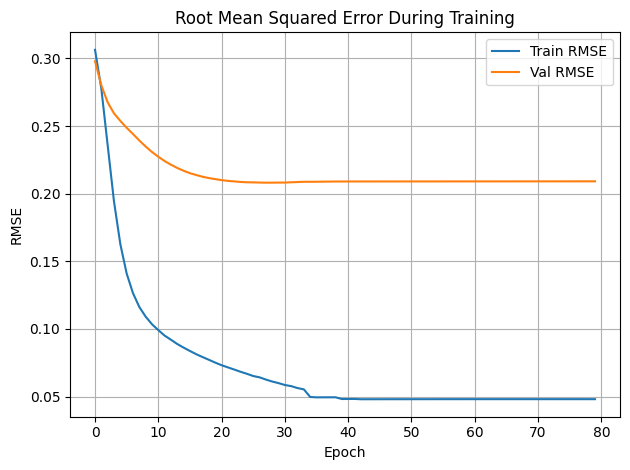

In [89]:

plt.plot(history.history['root_mean_squared_error'], label='Train RMSE')
plt.plot(history.history['val_root_mean_squared_error'], label='Val RMSE')
plt.title('Root Mean Squared Error During Training')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Inference

In [92]:
# Pastikan kolom User-ID berupa string
user_based_df['User-ID'] = user_based_df['User-ID'].astype(str)
books_df['ISBN'] = books_df['ISBN'].astype(str)

# Pastikan semua key encoding adalah string
user_to_user_encoded = {str(k): v for k, v in user_to_user_encoded.items()}
user_encoded_to_user = {v: k for k, v in user_to_user_encoded.items()}
isbn_encoded = {str(k): v for k, v in isbn_encoded.items()}
isbn_encoded_to_isbn = {v: k for k, v in isbn_encoded.items()}

# 1. Pilih user dari data yang memiliki cukup rating
user_counts = user_based_df['User-ID'].value_counts()
eligible_users = user_counts[user_counts >= 5].index.tolist()
user_id = random.choice(eligible_users)

print(f" Menggunakan user acak: {user_id}")

# 2. Tambahkan user ke encoding jika belum ada
if user_id not in user_to_user_encoded:
    new_id = len(user_to_user_encoded)
    user_to_user_encoded[user_id] = new_id
    user_encoded_to_user[new_id] = user_id

# 3. Mapping kolom user, book, rating untuk user yang dipilih
user_mask = user_based_df['User-ID'] == user_id
user_based_df.loc[user_mask, 'user'] = user_to_user_encoded[user_id]
user_based_df.loc[user_mask, 'book'] = user_based_df.loc[user_mask, 'ISBN'].map(isbn_encoded)
user_based_df.loc[user_mask, 'rating'] = user_based_df.loc[user_mask, 'Book-Rating'].astype(np.float32)

# 4. Jalankan rekomendasi
books_visited_by_user = user_based_df[user_based_df['User-ID'] == user_id]
books_not_visited = books_df[~books_df['ISBN'].isin(books_visited_by_user['ISBN'].values)]['ISBN']
books_not_visited = list(set(books_not_visited).intersection(set(isbn_encoded.keys())))
books_not_visited_encoded = [[isbn_encoded.get(x)] for x in books_not_visited]

if len(books_not_visited_encoded) == 0:
    print(f" Tidak ada buku yang bisa direkomendasikan untuk user {user_id}.")
else:
    user_encoder = user_to_user_encoded.get(user_id)
    user_book_array = np.hstack(
        ([[user_encoder]] * len(books_not_visited_encoded), books_not_visited_encoded)
    )

    # 5. Prediksi rating dan pilih top 10
    ratings = model.predict(user_book_array).flatten()
    top_ratings_indices = ratings.argsort()[-10:][::-1]
    recommended_book_isbns = [
        isbn_encoded_to_isbn.get(books_not_visited_encoded[x][0]) for x in top_ratings_indices
    ]

    # 6. Tampilkan hasil
    print(' Menampilkan rekomendasi untuk User-ID:', user_id)
    print('=' * 50)
    print(' Buku-buku yang disukai user:')
    print('-' * 50)

    # Ambil top 5 buku dengan rating tertinggi dari user
    top_books_user = (
        books_visited_by_user.sort_values(by='rating', ascending=False)
        .head(5)['ISBN'].values
    )

    # DEBUG: Periksa data
    print(" DEBUG INFO:")
    print(f" Top ISBN dari user: {top_books_user}")
    print(f" ISBN rekomendasi: {recommended_book_isbns}")
    print(f" Jumlah buku di books_df: {len(books_df)}")
    print(f" Kolom di books_df: {list(books_df.columns)}")

    # Periksa apakah ISBN ada di books_df
    books_df_match = books_df[books_df['ISBN'].isin(top_books_user)]
    print(f" Buku ditemukan untuk user: {len(books_df_match)}")

    recommended_books_match = books_df[books_df['ISBN'].isin(recommended_book_isbns)]
    print(f" Buku rekomendasi ditemukan: {len(recommended_books_match)}")

    print("\n" + "="*50)

    # Tampilkan buku yang disukai user
    if len(books_df_match) > 0:
        print(" Buku-buku yang disukai user:")
        for idx, row in books_df_match.iterrows():
            # Akses kolom dengan benar
            title = row['Book-Title'] if 'Book-Title' in row else 'Unknown Title'
            author = row['Book-Author'] if 'Book-Author' in row else 'Unknown Author'
            isbn = row['ISBN']

            # Ambil rating dari user untuk buku ini
            user_rating = books_visited_by_user[books_visited_by_user['ISBN'] == isbn]['rating'].iloc[0]

            print(f"    {title}")
            print(f"     {author}")
            print(f"    Rating: {user_rating}")
            print(f"    ISBN: {isbn}")
            print()
    else:
        print(" Tidak ada informasi detail untuk buku yang disukai user.")
        # Coba tampilkan ISBN yang tersedia di books_df
        sample_isbns = books_df['ISBN'].head(10).tolist()
        print(f" Contoh ISBN yang tersedia di books_df: {sample_isbns}")

    print('-' * 50)
    print('✨ Rekomendasi 10 buku teratas:')
    print('-' * 50)

    # Tampilkan rekomendasi
    if len(recommended_books_match) > 0:
        for idx, row in recommended_books_match.iterrows():
            title = row['Book-Title'] if 'Book-Title' in row else 'Unknown Title'
            author = row['Book-Author'] if 'Book-Author' in row else 'Unknown Author'
            isbn = row['ISBN']

            # Ambil predicted rating
            isbn_idx = recommended_book_isbns.index(isbn)
            predicted_rating = ratings[top_ratings_indices[isbn_idx]]

            print(f"    {title}")
            print(f"     {author}")
            print(f"    Predicted Rating: {predicted_rating:.2f}")
            print(f"    ISBN: {isbn}")
            print()
    else:
        print(" Tidak ada informasi detail untuk buku rekomendasi.")
        print(" Kemungkinan masalah:")
        print("   1. ISBN rekomendasi tidak ada di books_df")
        print("   2. Format ISBN tidak sesuai")
        print("   3. Data books_df tidak lengkap")

        # Tampilkan beberapa ISBN untuk debug
        if len(recommended_book_isbns) > 0:
            print(f"    ISBN yang dicari: {recommended_book_isbns[:5]}")

        # Periksa apakah ada ISBN yang mirip
        for isbn in recommended_book_isbns[:3]:
            similar = books_df[books_df['ISBN'].str.contains(isbn[:5], na=False)]
            if len(similar) > 0:
                print(f"    ISBN mirip dengan {isbn}: {similar['ISBN'].iloc[0]}")



 Menggunakan user acak: 212002
476/476 ━━━━━━━━━━━━━━━━━━━━ 0s 389us/step
 Menampilkan rekomendasi untuk User-ID: 212002
 Buku-buku yang disukai user:
--------------------------------------------------
 DEBUG INFO:
 Top ISBN dari user: ['3442720621' '3404142357' '3442352266' '3442726247' '3404142780']
 ISBN rekomendasi: ['1565548353', '1571458506', '1555611435', '2290312924', '1571456988', '1563054671', '3499224615', '1841721522', '1563893339', '1580050158']
 Jumlah buku di books_df: 271357
 Kolom di books_df: ['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']
 Buku ditemukan untuk user: 5
 Buku rekomendasi ditemukan: 10

 Buku-buku yang disukai user:
    Tote lÃ?Â¼gen nicht.
     Kathy Reichs
    Rating: 8.0
    ISBN: 3442352266

    Geschehnisse am Wasser.
     Kerstin Ekman
    Rating: 9.0
    ISBN: 3442720621

    Der zweite Mord.
     Helene Tursten
    Rating: 8.0
    ISBN: 3442726247

    At E.R.O.S.
     Greg I

In [95]:
# Fungsi tambahan untuk debug
def debug_recommendation_system():
    """
    Fungsi untuk debugging sistem rekomendasi
    """
    print("\n DEBUGGING RECOMMENDATION SYSTEM")
    print("="*50)

    print(" Dataset Info:")
    print(f"   - books_df shape: {books_df.shape}")
    print(f"   - user_based_df shape: {user_based_df.shape}")
    print(f"   - books_df columns: {list(books_df.columns)}")
    print(f"   - user_based_df columns: {list(user_based_df.columns)}")

    print("\n Sample Data:")
    print("books_df sample:")
    print(books_df[['ISBN', 'Book-Title', 'Book-Author']].head(3))

    print("\nuser_based_df sample:")
    print(user_based_df[['User-ID', 'ISBN', 'Book-Rating']].head(3))

    print("\n Encoding Info:")
    print(f"   - Total users encoded: {len(user_to_user_encoded)}")
    print(f"   - Total books encoded: {len(isbn_encoded)}")

    # Periksa konsistensi ISBN
    user_isbns = set(user_based_df['ISBN'].unique())
    book_isbns = set(books_df['ISBN'].unique())
    common_isbns = user_isbns.intersection(book_isbns)

    print(f"\n ISBN Analysis:")
    print(f"   - Unique ISBNs in user_based_df: {len(user_isbns)}")
    print(f"   - Unique ISBNs in books_df: {len(book_isbns)}")
    print(f"   - Common ISBNs: {len(common_isbns)}")
    print(f"   - Missing in books_df: {len(user_isbns - book_isbns)}")

    if len(user_isbns - book_isbns) > 0:
        print(f"   - Sample missing ISBNs: {list(user_isbns - book_isbns)[:5]}")

# Panggil fungsi debug
debug_recommendation_system()


 DEBUGGING RECOMMENDATION SYSTEM
 Dataset Info:
   - books_df shape: (271357, 8)
   - user_based_df shape: (28011, 6)
   - books_df columns: ['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']
   - user_based_df columns: ['User-ID', 'ISBN', 'Book-Rating', 'user', 'book', 'rating']

 Sample Data:
books_df sample:
         ISBN            Book-Title           Book-Author
0  0195153448   Classical Mythology    Mark P. O. Morford
1  0002005018          Clara Callan  Richard Bruce Wright
2  0060973129  Decision in Normandy          Carlo D'Este

user_based_df sample:
       User-ID        ISBN  Book-Rating
781854  172027  1569472424          8.0
670266  264149  8401418844          8.0
986889  101851  1565042166          8.0

 Encoding Info:
   - Total users encoded: 10501
   - Total books encoded: 15219

 ISBN Analysis:
   - Unique ISBNs in user_based_df: 15219
   - Unique ISBNs in books_df: 271357
   - Common ISBNs: 15219


Encoding User dan Book ID: Menyusun encoding untuk ID pengguna dan ISBN buku.

Rekomendasi:

Memilih pengguna acak dengan rating yang cukup.

Mengambil daftar buku yang belum dinilai oleh pengguna.

Menghitung prediksi rating untuk buku yang belum dinilai, dan memilih 10 buku teratas berdasarkan prediksi rating.

# Insight dari Modeling Collaborative Filtering

## 1. Pendekatan Personalized Recommender
Model *Collaborative Filtering* bekerja dengan cara memanfaatkan interaksi pengguna dengan item (dalam hal ini, buku) untuk memprediksi preferensi yang belum terungkap. Dengan kata lain, model ini memberikan rekomendasi yang lebih personal, berdasarkan data historis pengguna.

## 2. Penggunaan Embeddings untuk Representasi
Menggunakan *embeddings* untuk pengguna dan buku memungkinkan representasi yang lebih kompak dan efektif dalam menangkap hubungan tersembunyi antara pengguna dan item. Ini sangat mengurangi kompleksitas komputasi, terutama saat bekerja dengan data besar seperti dataset buku dan rating.

## 3. Regularization untuk Mencegah Overfitting
Regularisasi L2 yang digunakan pada layer embedding berfungsi untuk mencegah model overfitting, memastikan model generalisasi dengan baik saat memberikan rekomendasi untuk data yang tidak terlihat sebelumnya.

## 4. Model Menggunakan Feedback Explicit
Dengan mengandalkan rating eksplisit (misalnya rating 1-10 atau 1-5) yang diberikan pengguna terhadap buku, model dapat memprediksi buku-buku yang disukai pengguna meskipun mereka belum pernah memberi rating pada buku tersebut.

## 5. Evaluasi dengan Root Mean Squared Error (RMSE)
Untuk mengukur seberapa baik model dalam memprediksi rating yang belum terlihat, kita menggunakan metrik RMSE. Semakin rendah nilai RMSE, semakin baik model dalam memprediksi rating dan, pada gilirannya, memberikan rekomendasi yang lebih akurat.

## 6. Keunggulan dalam Skalabilitas
Model ini, meski sederhana, bisa diterapkan pada dataset besar dengan ribuan pengguna dan buku, selama ada cukup interaksi (rating) untuk memungkinkan pelatihan yang efektif. Hal ini sangat penting ketika berhadapan dengan sistem rekomendasi dunia nyata, di mana volume data sangat besar.

## 7. Tantangan Data Sparsity
Salah satu tantangan utama dalam *Collaborative Filtering* adalah data sparsity, yaitu banyaknya item (buku) yang belum pernah dinilai oleh sebagian besar pengguna. Meski demikian, model ini tetap mampu memberikan rekomendasi berdasarkan pola umum antar pengguna dengan preferensi serupa.

## 8. Pentingnya Hyperparameter Tuning
Ukuran embedding dan regularisasi sangat memengaruhi kinerja model. Mencari kombinasi yang tepat antara ukuran embedding dan tingkat regularisasi dapat meningkatkan akurasi prediksi dan kualitas rekomendasi.

## 9. Sistem Rekomendasi yang Mudah Diinterpretasikan
Sistem ini relatif mudah untuk diimplementasikan dan dipahami, sehingga sangat cocok untuk aplikasi di berbagai bidang, seperti e-commerce, platform media sosial, dan streaming musik atau video, di mana rekomendasi berbasis preferensi pengguna sangat dibutuhkan.

---

### Kesimpulan
Model *Collaborative Filtering* yang diimplementasikan ini efektif dalam memberikan rekomendasi berbasis preferensi pengguna dan buku, menggunakan embedding untuk merepresentasikan pengguna dan buku. Walaupun terdapat tantangan seperti data sparsity, model ini cukup handal dalam memberikan hasil yang relevan selama data yang digunakan cukup representatif.
